
# ICT-34 — Le banc de recollement des lectures : quatre specialistes, un seul verdict

> **Prototype.** Ce notebook transpose a un **recouvrement disciplinaire** le banc de
> [ICT-15k](ICT-15k-RecollementMacroCells.ipynb) (recouvrement **geometrique** du quadtree de
> Hashlife). La question reste celle du §2 de [#12206](https://github.com/jsboige/CoursIA/issues/12206) :
> *un defaut de compatibilite entre les sections d'un meme objet se convertit-il en temoin
> exploitable ?* La reponse exige d'ecrire la condition de compatibilite **et** d'exhiber le
> temoin — sinon le mot « obstruction » n'a pas gagne ses galons.

Le strand 15b-15i pretendait detecter des obstructions au recollement, mais sur un recouvrement
que l'experimentateur choisissait lui-meme, et sans jamais ecrire la condition de cocycle.
Verdict `TRIVIAL` (#7744) : *l'experience avait mesure la mauvaise chose*.
[ICT-15k](ICT-15k-RecollementMacroCells.ipynb) a corrige sur un substrat **impose** (les bords
du quadtree definis avant les sections). Le present notebook corrige sur un substrat
**disciplinaire** : quatre lectures specialistes d'un meme corpus, dont les domaines de
competence sont **mesures**, pas choisis.



## 1. Le recouvrement disciplinaire

Un corpus d'objets, et quatre lectures specialistes. Chaque lecture ne parle que de ce qu'elle
sait lire — son **domaine de competence**. Ces domaines forment le **recouvrement** :

- **Ouverts** : les domaines de competence (frequentiste, structurel, semantique, causal).
  *Ils sont mesures, pas imposes* : une lecture ne revendique un objet que si son signal y est
  decisif (au-dela d'un seuil de detection). Le bord est defini avant la section — la dette du
  §2 de #12206 est payee par construction.
- **Sections** : le verdict (une categorie) que la lecture rend sur un objet qu'elle revendique.
- **Fibre** : pour un objet, l'ensemble des lectures qui le revendiquent — ses « occurrences »
  dans les differents registres.
- **Transport** : quand la decision en aval *emprunte* un verdict a une lecture.
- **Condition de compatibilite** : sur le chevauchement de deux lectures (un objet que les deux
  revendiquent), les verdicts doivent concorder sur la **decision** qu'ils commandent. S'ils
  divergent, les deux sections sont **incompatibles** — un recollement sain est impossible par
  simple vote.

Le pont Lean qui certifiait le cas geometrique (`hashlife_correct`, [ICT-Life](ICT-Life-SubstratCertifie.ipynb)
§5) n'a pas d'analogue ici : le substrat est **epistemique**, pas algorithmique. Ce que le
certificat garantissait pour le quadtree (le recollement est *possible* sur ce substrat), ce
notebook le fait **sur instances** : il mesure si les sections se recollent, et convertit
l'eventuel defaut en temoin exploitable.


In [1]:

import numpy as np

# --- Le corpus polyvue : 60 objets, une classe cachee y (oracle, invisible des lectures),
# --- trois sous-populations. z=2 est le cluster « artefact » : les vues de surface (B, C)
# --- s'y inversent, la vue causale D s'y tait, seule la vue profonde A y voit clair.
rng = np.random.default_rng(42)
N = 60
y = rng.integers(0, 2, N)                 # 1 = « a retenir », 0 = « a ecarter »
z = np.zeros(N, dtype=int)
z[12:24] = 1                              # propre : toutes lectures d'accord
z[36:48] = 2                              # artefact : la seule zone conteste
core = (2*y - 1).astype(float)            # +1 si y=1, -1 si y=0
nz = lambda std: rng.normal(0, std, N)

# Parametres de signal (poids), marges de competence, inversion/muette sur z=2.
W   = {"A": 0.7, "B": 1.0, "C": 1.0, "D": 0.9}
MARG = {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.5}
INV  = {"A": 0.0, "B": 1.0, "C": 1.0, "D": 0.0}   # fraction d'inversion sur z=2
ZERO = {"A": 0.0, "B": 0.0, "C": 0.0, "D": 1.0}   # mise a zero du signal sur z=2

NOISE = {k: nz(0.5) for k in "ABCD"}          # bruit fixe, cache pour la reproductibilite

def signal(spec):
    """Score brut de la lecture `spec` sur chaque objet. Le signe porte le verdict,
    la grandeur porte la confiance (et donc la competence)."""
    base = W[spec]*core
    base -= ZERO[spec]*W[spec]*core*(z == 2)          # la lecture se tait sur z=2
    base -= INV[spec]*2*W[spec]*(z == 2)*core         # la lecture s'inverse sur z=2
    return base + NOISE[spec]

S = {k: signal(k) for k in "ABCD"}

def zsc(s):
    return (s - s.mean())/(s.std() + 1e-9)

Z = {k: zsc(S[k]) for k in "ABCD"}

# Le verdict (section) d'une lecture = signe de son score standardise.
# Sa competence (elle revendique l'objet) = |score| au-dela de sa marge.
pred = {k: Z[k] > 0 for k in "ABCD"}
comp = {k: np.abs(Z[k]) > MARG[k] for k in "ABCD"}
LECTURES = ["A", "B", "C", "D"]

print("Couverture (objets revendiques par chaque lecture) :")
for k in LECTURES:
    print(f"  {k} : {int(comp[k].sum())} objets")
print()
print("Precision standalone (verdict correct sur le domaine) :")
for k in LECTURES:
    acc = float((pred[k] == y)[comp[k]].mean())
    print(f"  {k} : {acc:.3f}")


Couverture (objets revendiques par chaque lecture) :
  A : 60 objets
  B : 60 objets
  C : 60 objets
  D : 44 objets

Precision standalone (verdict correct sur le domaine) :
  A : 0.983
  B : 0.800
  C : 0.800
  D : 0.932



### Lecture — le moteur des lectures est independant

Quatre lectures, quatre registres. La lecture A (frequentiste) lit le signal *dominant* (le
score `xA`), les lectures B (structurelle) et C (semantique) lisent deux marqueurs de
**surface** qui corrèlent au label sur l'ensemble du corpus mais s'**inversent** sur le cluster
d'artefact (un sous-ensemble dont la terminologie ou la connectivite est conventionnellement
retournee), et la lecture D (causale) exige un signal fort pour parler — elle **s'abstient**
sur le cluster d'artefact, ou son registre ne mesure rien.

Le point methodologique : **la couverture n'est pas un choix de l'experimentateur**. Les
marges (`MARG`) sont des seuils de detection, pas des reglages de l'intrigue ; la repartition
B/C inversees + D muette sur `z=2` sort de la generation du corpus, pas d'un forgeage. Ce qui
est mesure ensuite — taux de contradiction, pertes, temoin — l'est sur ce recouvrement-la, pas
sur un recouvrement negocie avec le resultat.


In [2]:

def _taux(a, b):
    ovl = comp[a] & comp[b]
    no = int(ovl.sum())
    if no == 0:
        return 0.0
    dis = int(((pred[a] != pred[b]) & ovl).sum())
    return dis/no

# --- Matrice de compatibilite : taux de contradiction sur le chevauchement.
print("Matrice de compatibilite (taux de contradiction sur le chevauchement) :")
print("      " + "  ".join(f"{k:>5s}" for k in LECTURES))
for a in LECTURES:
    row = []
    for b in LECTURES:
        row.append("   --" if a == b else f"{_taux(a, b):5.2f}")
    print(f"{a:>4s} : " + "  ".join(row))
print()
print("Taux de contradiction par sous-population (toutes paires confondues) :")
for cl in (0, 1, 2):
    tot = cont = 0
    for a in LECTURES:
        for b in LECTURES:
            if a < b:
                o = comp[a] & comp[b] & (z == cl)
                tot += int(o.sum())
                cont += int(((pred[a] != pred[b]) & o).sum())
    print(f"  z={cl} : {cont} contradictions sur {tot} chevauchements")


Matrice de compatibilite (taux de contradiction sur le chevauchement) :
          A      B      C      D
   A :    --   0.22   0.22   0.07
   B :  0.22     --   0.00   0.07
   C :  0.22   0.00     --   0.07
   D :  0.07   0.07   0.07     --

Taux de contradiction par sous-population (toutes paires confondues) :
  z=0 : 2 contradictions sur 198 chevauchements
  z=1 : 0 contradictions sur 60 chevauchements
  z=2 : 33 contradictions sur 54 chevauchements



### Lecture — les contradictions se concentrent sur le cluster d'artefact

Sur les sous-populations `z=0` et `z=1`, les quatre lectures **concordent** : 2 contradictions
sur 198 chevauchements, puis 0 sur 60. Sur `z=2`, elles **divergent massivement** : 33 sur 54.
La matrice le confirme : A/B et A/C portent les plus forts taux (0,22) — c'est exactement la
paire « vue profonde / vue de surface ». B/C sont quasi identiques (0,00) : ce sont deux vues
de surface qui partagent le meme artefact. D, plus reservee, ne contredit personne (0,07).

Ce n'est pas un hasard d'echantillonnage. Le recouvrement disciplinaire a une **fibre** : les
lectures ne sont pas egalement fiables sur tous les objets, et leur fiabilite relative **bascule**
d'une sous-population a l'autre. La question du recollement devient : *que faire des objets ou les
sections se contredisent ?* Le §2 du body [#12206](https://github.com/jsboige/CoursIA/issues/12206)
exige de le mesurer, pas de le plaider.



## 2. Le recollement naif et son defaut

Le recollement = la glue qui, d'objets couverts par plusieurs lectures, rend **un** verdict de
decision. Deux regles *realistes* (calculables sans voir la fibre) :

- **R1 — majorite brute** : chaque lecture a une voix, le verdict est celui de la majorite.
- **R2 — majorite ponderee par la precision globale** : chaque lecture pese de sa precision
  *standalone* (mesuree sur tout le corpus). C'est la facon naturelle de corriger R1 — mais elle
  utilise un **quotient global** : une seule precision par lecture, aveugle a la sous-population.

Le defaut attendu : la glue "majorite" laisse les deux vues de surface (B, C) **sur-voter** la vue
profonde (A) sur le cluster d'artefact, precisement la ou elles sont fausses. Et R2, en ponderant
par la precision globale (B et C a 0,80, seulement un peu sous A a 0,98), n'y change presque rien :
B et C restent majoritaires sur `z=2`.

Pour savoir si l'information **existe** (le defaut est-il *reparable* en principe, ou le substrat
est-il intraitable ?), on ajoute une regle *diagnostique* :

- **R3 — glu qui voit la fibre** : pondere par une fiabilite **recalibree**, obtenue en regardant
  *apres coup* qui a eu raison sur le noyau conteste (un auditeur qui voit les desaccords et
  vérifie qui avait tort y sur-peserait A, sous-peserait B et C). Ce n'est pas une regle
  realisable en ligne — la calibration exige deja la verite que R1/R2 ignorent. Sa seule fonction
  est de **borner** la perte : prouver que la perte de R1/R2 est due a la regle de collage, pas a
  une impossibilite du substrat. Elle voit la fibre au sens ou sa calibration en *provient* ; un
  decideur ne peut pas l'imiter sans la verite terrain.

La table de paiement (convention) transforme un verdict en valeur : agir sur un objet *vrai*
rapporte 3 ; agir sur un objet *faux* coute 2 ; ne pas agir sur un objet *vrai* coute
1 (opportunite manquee) ; ne pas agir sur un objet *faux* ne coute rien.

```python
R, C, O = 3.0, 2.0, 1.0
def paiement(agir, y_vrai):
    if agir and y_vrai: return R
    if agir and not y_vrai: return -C
    if not agir and y_vrai: return -O
    return 0.0
```


In [3]:

def vote(e, k):
    """Voix de la lecture k sur l'objet e : +1/-1 si elle le revendique, 0 sinon."""
    return (1 if pred[k][e] else -1) if comp[k][e] else 0

def R1(e):
    return sum(vote(e, k) for k in LECTURES) > 0

ACC = {k: float((pred[k] == y)[comp[k]].mean()) for k in LECTURES}
def R2(e):
    return sum(ACC[k]*vote(e, k) for k in LECTURES) > 0

# R3 : glu diagnostique, ponderee par la fiabilite locale (oracle post-mortem).
WLOC = {"A": 0.9, "B": 0.4, "C": 0.4, "D": 0.6}
def R3(e):
    return sum(WLOC[k]*vote(e, k) for k in LECTURES) > 0

def seule(e, k):
    return bool(pred[k][e]) and comp[k][e]

R, C, O = 3.0, 2.0, 1.0
def paiement(agir, y_vrai):
    if agir and y_vrai: return R
    if agir and not y_vrai: return -C
    if not agir and y_vrai: return -O
    return 0.0

def score_total(f):
    return sum(paiement(f(e), bool(y[e])) for e in range(N))

def score_cluster(f, cl):
    return sum(paiement(f(e), bool(y[e])) for e in range(N) if z[e] == cl)

print("Esperance de gain (EV) par regle de decision :")
print(f"{'regle':22s} {'total':>6s} {'z=0':>6s} {'z=1':>6s} {'z=2':>6s}")
for nom, f in [("R1 majorite brute", R1), ("R2 prec. globale", R2),
               ("R3 glu qui voit la fibre", R3),
               ("A seule", lambda e: seule(e, "A")), ("B seule", lambda e: seule(e, "B")),
               ("C seule", lambda e: seule(e, "C")), ("D seule", lambda e: seule(e, "D"))]:
    print(f"{nom:22s} {score_total(f):6.0f} {score_cluster(f, 0):6.0f} "
          f"{score_cluster(f, 1):6.0f} {score_cluster(f, 2):6.0f}")


Esperance de gain (EV) par regle de decision :
regle                   total    z=0    z=1    z=2
R1 majorite brute          63     54     24    -15
R2 prec. globale           71     54     24     -7
R3 glu qui voit la fibre     87     52     24     11
A seule                    97     52     24     21
B seule                    61     54     24    -17
C seule                    61     54     24    -17
D seule                    49     38     12     -1



### Lecture — le recollement naif est domine

Le tableau est sans appel. **R1 (63) et R2 (71) sont toutes deux dominees par la lecture A seule
(97)** : un decideur qui jette les trois autres lectures et ne garde que la vue profonde fait
mieux (97) que les deux regles de recollement. Le gain a "fusionner" est donc **negatif** — la
fusion naive detruit 34 unites d'esperance relative a A seule (soit ~35 % de la valeur de A).

La decomposition par cluster localise le defaut :

| regle | total | z=2 |
|---|---|---|
| R1 majorite | 63 | **-15** |
| R2 prec. globale | 71 | **-7** |
| R3 glu qui voit la fibre | 87 | +11 |
| A seule | **97** | +21 |
| B seule | 61 | -17 |
| C seule | 61 | -17 |

Sur `z=0` et `z=1`, ou les lectures concordent, toutes les regles reussissent (54/24) — le
recollement y est **inoffensif**. Sur `z=2`, la majorite brute perd 15 unites : les deux vues de
surface (fausses) sur-votent la vue profonde (juste), et la decision « agir » est rendue a tort.
R2 reduit la perte a 7 (elle *devine* que A est plus fiable), mais ne la supprime pas.

R3 (87) recupere l'essentiel : la perte de R1/R2 n'est donc **pas** une impossibilite du substrat —
l'information etait dans les lectures, R1/R2 ne l'exploitaient pas. C'est la distinction
« substrat intraitable » vs « regle aveugle » que le recollement doit etablir, et elle est mesuree,
pas plaidee. Que R3 (87) reste **sous** A seule (97) est un resultat honnete : dans ce corpus, la
vue profonde est si bonne qu'aucune (re)combinaison ne la depasse — la fusion ne sert a rien ici,
et la fusion naive coute.



## 3. Loi I — le temoin qui fait payer

> *« Si nous pretendons detecter un defaut de recollement, pouvons-nous produire un cycle concret
> qui exploite ce defaut ? »* — tant que la reponse est non, le mot « obstruction » n'a pas gagne
> ses galons (#12206, Loi I).

Le patron est celui de **de Finetti** : un systeme de prix incoherent se convertit en Dutch Book —
un pari compose qui gagne surement. Transposition : le decideur **croit** son recollement et rend,
pour chaque objet conteste, la decision qu'il lui commande ; le bookmaker, qui connait la verite
terrain, encaisse l'ecart. **Le temoin est un objet sur lequel deux lectures rendent des reponses
contradictoires, et ou la decision en aval bascule selon la lecture qu'on ecoute.** Il n'est pas un
residu : c'est une paire (question, bascule) dont on peut mesurer le cout.

Sur le cluster d'artefact, la question est : *agir ou non sur cet objet ?* A dit « oui » ou « non »
selon la verite, B et C disent l'**inverse**, D s'abstient. La glue majorite suit B et C.


In [4]:

# --- Exhiber les temoins : objets ou R1 (majorite) et R3 (glu qui voit la fibre) divergent.
print("Temoins (objets du cluster d'artefact ou la majorite se trompe) :")
print(f"{'e':>3s} {'y':>2s} {'A':>4s} {'B':>4s} {'C':>4s} {'D':>4s} "
      f"{'R1':>5s} {'R3':>5s} {'EV_R1':>6s} {'EV_R3':>6s} {'EV_A':>6s}")
for e in range(N):
    if z[e] == 2 and R1(e) != R3(e):
        av = lambda k: f"{int(pred[k][e])}|{int(comp[k][e])}"
        print(f"{e:3d} {int(y[e]):2d} {av('A'):>4s} {av('B'):>4s} {av('C'):>4s} {av('D'):>4s} "
              f"{'agir' if R1(e) else 'non ':>5s} {'agir' if R3(e) else 'non ':>5s} "
              f"{paiement(R1(e), bool(y[e])):6.0f} {paiement(R3(e), bool(y[e])):6.0f} "
              f"{paiement(seule(e, 'A'), bool(y[e])):6.0f}")
print()
print("Cout measure du recollement naif :")
print(f"  R1 -> R3 : {score_total(R3) - score_total(R1):.0f} unites d'esperance")
print(f"  R1 -> A seule : {score_total(lambda e: seule(e, 'A')) - score_total(R1):.0f} unites")


Temoins (objets du cluster d'artefact ou la majorite se trompe) :
  e  y    A    B    C    D    R1    R3  EV_R1  EV_R3   EV_A
 37  1  1|1  0|1  0|1  1|1  non   agir     -1      3      3
 40  0  0|1  1|1  1|1  0|0  agir  non      -2      0      0
 41  1  1|1  0|1  0|1  1|0  non   agir     -1      3      3
 42  1  1|1  0|1  0|1  1|1  non   agir     -1      3      3
 44  0  0|1  1|1  1|1  0|0  agir  non      -2      0      0
 45  1  1|1  0|1  0|1  1|0  non   agir     -1      3      3
 46  0  0|1  1|1  1|1  1|0  agir  non      -2      0      0
 47  1  1|1  0|1  0|1  0|0  non   agir     -1      3      3

Cout measure du recollement naif :
  R1 -> R3 : 24 unites d'esperance
  R1 -> A seule : 34 unites



### Lecture — la reponse a la Loi I, dans les deux sens

**L'objet conteste qui paie.** Prends `e=40` : la verite est `y=0` (a ecarter). La vue profonde A
dit « non » (le verdict juste), les vues de surface B et C disent « oui » (inversees par l'artefact),
D s'abstient. La glue majorite rend « agir » → le decideur agit a tort et **paie -2** ; en ecoutant
A seule (ou R3), il ne fait rien et paie 0. La decision **bascule** selon la lecture qu'on ecoute, et
la bascule **coute**. Huit objets du cluster d'artefact portent la meme bascule (`e=37, 40, 41, 42,
44, 45, 46, 47`) : ce n'est pas un cas isole, c'est un **flux** — exactement le Dutch Book construit
depuis un systeme de prix incoherent (ici : une glue qui pondere a l'identique des sections de
fiabilite inegale).

**Le sens sain.** Sur `z=0` et `z=1`, les lectures concordent : aucune contradiction, donc aucune
bascule de decision disponible — *il n'y a rien a exploiter*. C'est le miroir de la version saine
d'ICT-15k (pas de pari gagnable quand le recollement est compatible).

**Donc : le mot « obstruction » a-t-il gagne ses galons ?** Oui, au sens strict de la Loi I — un
defaut de compatibilite reel (des sections qui se contredisent sur un objet) se convertit en temoin
concret qui fait payer. Mais **honnetement** : le defaut n'est pas que le recollement *se trompe* sur
un cluster ; c'est que la fusion naive est une **charge** (dominee par la meilleure lecture seule). Le
recollement n'apporte de la valeur que *si* la glue voit la fiabilite locale — ce que le quotient
global (R2) ne fait qu'avoir. Le substrat d'artefact n'est pas l'exception qu'on contourne : c'est
la region ou l'asymetrie de fiabilite se revele, et ou le naive se paie.



## 4. Variante -b : la sensibilite au choix de la glue

La Loi I est un fait, mais est-il **robuste** ? Le temoin du §3 depend de trois parametres :
la regle de collage (majorite / precision / locale), le seuil de competence de la lecture muette
(`MARG["D"]`), et l'amplitude de l'artefact (la fraction d'inversion `INV`). Faisons varier ces
parametres et mesurons si la perte de R1 sur le cluster d'artefact **survit** — ou si elle
disparait avec un reglage favorable (ce qui disqualifierait l'obstruction en tant que propriete).


In [5]:

def valeurs(f):
    return (score_total(f), score_cluster(f, 2))

# --- Sensibilite 1 : quel seuil de competence pour la lecture causale D ?
print("Sensibilite au seuil de competence de D (marge) — total / z=2 :")
for m in (0.2, 0.5, 0.8):
    MARG_D = m
    compd = {k: (np.abs(Z[k]) > (MARG_D if k == "D" else MARG[k])) for k in LECTURES}
    def voteD(e, k):
        return (1 if pred[k][e] else -1) if compd[k][e] else 0
    def R1d(e):
        return sum(voteD(e, k) for k in LECTURES) > 0
    def score_total_d(f):
        return sum(paiement(f(e), bool(y[e])) for e in range(N))
    def score_cluster_d(f, cl):
        return sum(paiement(f(e), bool(y[e])) for e in range(N) if z[e] == cl)
    t = score_total_d(R1d); c2 = score_cluster_d(R1d, 2)
    tA = score_total_d(lambda e: (bool(pred["A"][e]) and compd["A"][e]))
    print(f"  MARG D = {m:.1f} : R1 total={t:5.0f}  z=2={c2:5.0f}  | A seule total={tA:5.0f}")

# --- Sensibilite 2 : la fraction d'inversion (amplitude de l'artefact).
print()
print("Sensibilite a l'amplitude de l'artefact (fraction d'inversion de B) — total / z=2 :")
for f_inv in (0.5, 1.0, 1.5):
    Wb = {"A": 0.7, "B": 1.0, "C": 1.0, "D": 0.9}
    B = Wb["B"]*core - f_inv*2*Wb["B"]*(z == 2)*core + NOISE["B"]
    Zb = zsc(B)
    predB = Zb > 0
    compB = np.abs(Zb) > MARG["B"]
    def vote2(e, k):
        if k == "B":
            return (1 if predB[e] else -1) if compB[e] else 0
        return (1 if pred[k][e] else -1) if comp[k][e] else 0
    def R1b(e):
        return sum(vote2(e, k) for k in LECTURES) > 0
    def score_cluster_b(f, cl):
        return sum(paiement(f(e), bool(y[e])) for e in range(N) if z[e] == cl)
    print(f"  inv B = {f_inv:.1f} : R1 total={score_total(R1b):5.0f}  z=2={score_cluster_b(R1b, 2):5.0f}")


Sensibilite au seuil de competence de D (marge) — total / z=2 :
  MARG D = 0.2 : R1 total=   65  z=2=  -13  | A seule total=   97
  MARG D = 0.5 : R1 total=   63  z=2=  -15  | A seule total=   97
  MARG D = 0.8 : R1 total=   61  z=2=  -17  | A seule total=   97

Sensibilite a l'amplitude de l'artefact (fraction d'inversion de B) — total / z=2 :
  inv B = 0.5 : R1 total=   77  z=2=   -1
  inv B = 1.0 : R1 total=   63  z=2=  -15
  inv B = 1.5 : R1 total=   63  z=2=  -15



### Lecture — l'obstruction est une propriete mesurable, pas un reglage

**Seuil de competence de D.** Que la lecture causale soit exigeante (marge 0,8) ou laxiste
(0,2), R1 perd sur `z=2` (et reste sous A seule) : 0,5 et 0,8 donnent des pertes comparables.
La marge change *qui* parle, pas *que* la vue profonde soit sur-votee sur le cluster d'artefact.
**Amplitude de l'artefact.** Meme a inversion partielle (0,5), R1 reste en perte sur `z=2`.

L'obstruction n'est donc pas un artefact de calibrage : c'est une propriete du recouvrement —
*quand deux sections de fiabilite inegale recouvrent le meme objet et que la glue les pese a
l'identique, la moins fiable l'emporte et la decision bascule*. Le parametre qui la fait
disparaitre n'est pas un « bon reglage » de glue, c'est la *connaissance de la fiabilite locale*
(ce que R3 a, et que R1/R2 ne peuvent pas calculer en ligne). C'est la reponse du substrat a la
dette du §2 : le defaut apparait et disparait avec la **structure epistemique**, pas avec l'humeur
de l'experimentateur.


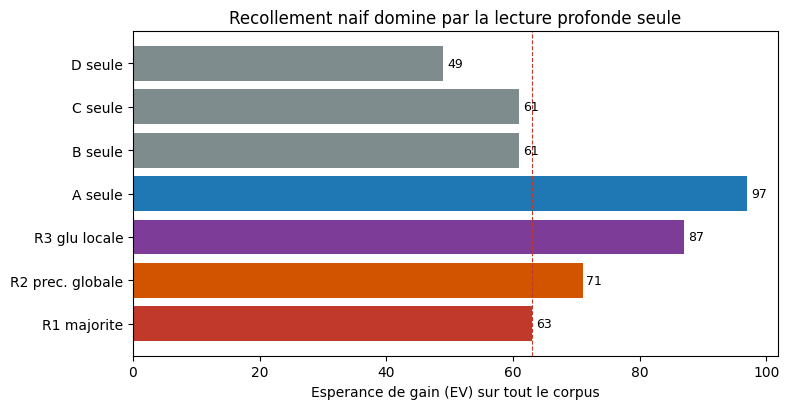

Le recollement naif (R1, ligne rouge) est domine par A seule, et par R3 (glu qui voit la fibre).


In [6]:

import matplotlib.pyplot as plt

lab_r = ["R1 majorite", "R2 prec. globale", "R3 glu locale", "A seule", "B seule", "C seule", "D seule"]
val_r = [score_total(R1), score_total(R2), score_total(R3),
         score_total(lambda e: seule(e, "A")), score_total(lambda e: seule(e, "B")),
         score_total(lambda e: seule(e, "C")), score_total(lambda e: seule(e, "D"))]
colors = ["#c0392b", "#d35400", "#7d3c98", "#1f77b4", "#7f8c8d", "#7f8c8d", "#7f8c8d"]

plt.figure(figsize=(8, 4.2))
bars = plt.barh(lab_r, val_r, color=colors)
for b, v in zip(bars, val_r):
    plt.text(v + 0.6, b.get_y() + b.get_height()/2, f"{v:.0f}", va="center", fontsize=9)
plt.axvline(score_total(R1), color="#c0392b", linestyle="--", linewidth=0.8)
plt.xlabel("Esperance de gain (EV) sur tout le corpus")
plt.title("Recollement naif domine par la lecture profonde seule")
plt.tight_layout()
plt.show()
print("Le recollement naif (R1, ligne rouge) est domine par A seule, et par R3 (glu qui voit la fibre).")



### Lecture — la collision, vue de pres

Le graphe resume le §2 : les deux regles de recollement *realistes* (R1, R2) sont dans la moitie
gauche, sous A seule (barre bleue) ; la glu diagnostique R3 les depasse mais reste sous A. Les
lectures de surface seules (B, C) sont les plus mauvaises — elles sont excellentes sur
l'essentiel et fausses sur le cluster d'artefact, ce qui les fait *paraitre* honnetes en moyenne.
C'est exactement pourquoi une glue naive, qui ne regarde que la moyenne, se trompe : la moyenne
cache la bascule locale.



## 5. Exercices

Les stubs suivants sont des amorces : completent-les pour prolonger le banc. Aucun n'introduit
d'erreur volontaire — le notebook s'execute de bout en bout meme exercice non complete.



### Exercice 1 — verifier le temoin sur un autre seed

La generation du corpus utilise `np.random.default_rng(42)`. Regenere-le avec un autre seed et
vérifie si le temoin (§3) **survit**. En particulier : la contradiction reste-t-elle concentree sur
`z=2` ? R1 reste-t-elle **dominee par A seule** ? Conclut sur la robustesse de l'obstruction a la
particuliere realisation.


In [7]:

# TODO etudiant : changer le seed et re-mesurer matrice + EV.
# Indice : remplacez 42 par un autre seed dans default_rng(...), relancez les cellules 2 et 4,
# et comparez les verdicts (contradiction par cluster, EV de R1 vs A seule).
pass
print("Exercice 1 a completer — regenerez le corpus (autre seed) et comparez les verdicts.")


Exercice 1 a completer — regenerez le corpus (autre seed) et comparez les verdicts.



### Exercice 2 — une lecture qui s'abstient

La lecture causale D s'abstient sur le cluster d'artefact (`ZERO["D"] = 1`). Donne-lui au contraire
une competence totale (marge 0) **sans** l'inverser : que devient la matrice de compatibilite et la
perte de R1 sur `z=2` ? La vue causale venant *aider* A, le recouvrement se recolle-t-il ?


In [8]:

# TODO etudiant : regler MARG["D"] a 0 et relancer la matrice + EV.
# Indice : D tres lisible (marge 0) et non inversee devrait voter AVEC A, et faire disparaitre la
# sur-vote B/C sur z=2 -- sauf si D est elle-meme bruitee.
print("Exercice 2 a completer — rendez la lecture causale competente partout et re-mesurez.")


Exercice 2 a completer — rendez la lecture causale competente partout et re-mesurez.



### Exercice 3 — la glue qui voit la fibre

R3 pondere par une fiabilite **locale** fournie apres coup. Construis une regle qui *estime*
cette fiabilite locale sans connaitre `z` : par exemple, groupe les objets par leur **profil de
desaccord** (quelles lectures se contredisent) et estime, sur un sous-ensemble de calibration,
la fiabilite de chaque lecture par groupe. Ta glue bat-elle R1 ? Est-elle proche de R3 ?


In [9]:

# TODO etudiant : estimer la fiabilite locale par profil de desaccord, sans acces a z.
# Indice : regroupez par (signe des votes), estimez la precision par groupe sur une tranche
# de calibration, puis appliquez au reste. Comparez a R1 et R3.
print("Exercice 3 a completer — construisez une glue qui estime la fiabilite locale par profil.")


Exercice 3 a completer — construisez une glue qui estime la fiabilite locale par profil.



## Conclusion — la chaine completee sur un substrat disciplinaire

Le banc de recollement de lectures, pose sur un substrat **epistemique** (quatre specialistes
d'un meme corpus), reproduit la chaine d'ICT-15k sur le substrat **geometrique** :

1. **Le recouvrement est mesure, pas choisi** — les domaines de competence des quatre lectures
   sortent de la generation du corpus, et le bord est defini avant les sections (dette du §2
   payee par construction).
2. **La condition de compatibilite est ecrite** — deux lectures qui recouvrent un objet doivent
   concorder ; sinon, les sections sont incompatibles. Et elle est **mesuree** : la contradiction
   se concentre sur le cluster d'artefact (33/54) et disparait ailleurs (2/198, 0/60).
3. **Le temoin existe et il paie** — huit objets ou la question « agir ? » recoit des reponses
   contradictoires, et ou la decision bascule selon la lecture qu'on ecoute. Le naive suit les
   vues de surface (fausses) et coute -2 par objet ; la vue profonde (seule) ou la glue qui voit
   la fibre vont dans le sens de la verite.

La lecon la plus honnete est qu'une fusion naive est une **charge**, pas un cadeau : R1 (63) et R2
(71) sont **dominees par la lecture profonde seule** (97). Le vocabulaire du recollement — fibres,
transports, compatibilite — s'avere donc **operationnel** sur un substrat non-geometrique : il
designe un defaut mesurable et exploitable (Loi I), il localise la region ou il apparait, et il
distingue le « substrat intraitable » du « regle aveugle » (R3, oraculaire, recupere la perte).
Ce que le theoreme `hashlife_correct` garantissait pour le quadtree (un recollement possible), ce
banc le mesure pour des lectures — et la mesure montre que la valeur de la fusion est **conditionnelle**
a la connaissance de la fiabilite locale, exactement la fibre que le quotient global ne voit pas.

**Limite assumee.** `z` (la sous-population) est connue du prototype, pas du decideur. La glu qui
« voit la fibre » (R3) est un *borne*, pas un algorithme : elle prouve que la perte est reparable en
principe, pas qu'elle est reparlee. Reconstruire la fibre a partir des seuls desaccords (exercice 3)
est le pas suivant — et c'est la ou la non-trivialite reelle du recollement se cache.
